# M2M PLIMS Data Volume Testing

#### Intro
Starting with the first deployment of the Coastal Pioneer Mid-Atlantic Bight (MAB) Array, OOI collected data from a plankton imaging instrument (McLane Research Labs Imaging Flow Cytobot) deployed at 7 meters depth on the near-surface instrument frame. The introduction of a new instrument to the physical OOI infrastructure required new parsing code and metadata to ingest the data into the OOI Cyberinfrastructure. Once ingested, the data will be available for machine-to-machine (M2M) download from OOI's THREDDS server and then pushed to Data Explorer on a near-real-time basis.

#### Problem
Review of data from the first deploymment (D00001) showed that the focus of the images severely deteriorated in Nov 2024. One possible cause, besides the expected gradual drift, is movement of the instrument by external forces. The internal as-sold mechanical design without modifications has proven to be sensitive to any impact to the housing. Tilting the instrument excesively can also allow parts to shift or trap air bubbles in the fluidic system lines.

#### Purpose
Telemetered data from the third PLIMS deployment (D00003) on Central Surface Mooring has been ingested into the Dev0 development platform after the Pioneer-22 Asset Management updates were tested in this emvironment. This is both a test of the parsers and an early examination at data volume produced in the most recent sample. 

#### Objectives:

* Test Output: Request HDR science, ADC science, and HDR engineering datasets.
* Dataset Review: Look for incorrect data values, types, or metadata and provide feedback to CI as needed. 
* Identify a Representative Sample: A sample with fewer but larger ROIs is expected to be a good candidate for one-time telemetry to the shore-side server to remotely assess image focus.

#### Supporting tools
If you want to run this notebook as-is, you will need to clone A. Reed's [ooinet repo](https://github.com/reedan88/OOINet) to your local machine and install it as a local dev repo (which adds it to your base path). You'll also need the [ooi_data_explorations repo](https://github.com/oceanobservatories/ooi-data-explorations). Lastly, this particular test is only intended for OOI operator use and requires access to the internal OOI team network.  

Whether individual sections of this notebook can successfully request, download, and analyze data depends on having the appropriate data ingested into the Dev0 environment.


In [1]:
# Import libraries
import os
import re
import netrc
import pandas as pd
import numpy as np
import xarray as xr
import warnings
from datetime import datetime, timezone, timedelta
warnings.filterwarnings("ignore")

# Import dask
import dask
from dask.diagnostics import ProgressBar

# Import pyplot and show interactive plots (inline still, I think)
import matplotlib.pyplot as plt
# Use the following Matplotlib backend in VS Code
%matplotlib ipympl
# The next backend could be used in other IDEs
# %matplotlib notebook 

In [2]:
# Import functions maintained by the OOI program staff
from ooinet import M2M
from ooi_data_explorations.common import get_vocabulary

---
## Request and load the data
Sub in ooinet-dev0-west.intra.oceanobservatories.org into the avaialbe API urls


In [3]:
for key in M2M.URLS:
    url = M2M.URLS.get(key)
    if "opendap" in url:
        M2M.URLS[key] = re.sub("opendap", "opendap-dev0.intra", url)
    else:
        M2M.URLS[key] = re.sub("ooinet","ooinet-dev0.intra", url)

Sub in dev0 OOINet credentials from netrc file

In [4]:
try:
    nrc = netrc.netrc()
    M2M.AUTH = nrc.authenticators('ooinet-dev0.intra.oceanobservatories.org')
    M2M.login, M2M.password = M2M.AUTH[0], M2M.AUTH[2]
    if M2M.AUTH is None:
        raise RuntimeError(
            'No entry found for machine ``ooinet-dev0.intra.oceanobservatories.org`` in the .netrc file')
except FileNotFoundError as e:
    raise OSError(e, os.strerror(e.errno), os.path.expanduser('~'))

In [5]:
M2M.URLS

{'data': 'https://ooinet-dev0.intra.oceanobservatories.org/api/m2m/12576/sensor/inv',
 'anno': 'https://ooinet-dev0.intra.oceanobservatories.org/api/m2m/12580/anno/find',
 'vocab': 'https://ooinet-dev0.intra.oceanobservatories.org/api/m2m/12586/vocab/inv',
 'asset': 'https://ooinet-dev0.intra.oceanobservatories.org/api/m2m/12587',
 'deploy': 'https://ooinet-dev0.intra.oceanobservatories.org/api/m2m/12587/events/deployment/inv',
 'preload': 'https://ooinet-dev0.intra.oceanobservatories.org/api/m2m/12575/parameter',
 'cal': 'https://ooinet-dev0.intra.oceanobservatories.org/api/m2m/12587/asset/cal',
 'fileServer': 'https://opendap-dev0.intra.oceanobservatories.org/thredds/fileServer/',
 'dodsC': 'https://opendap-dev0.intra.oceanobservatories.org/thredds/dodsC/',
 'goldCopy': 'https://thredds.dataexplorer.oceanobservatories.org/thredds/catalog/ooigoldcopy/public/',
 'goldCopy_fileServer': 'https://thredds.dataexplorer.oceanobservatories.org/thredds/fileServer/',
 'goldCopy_dodsC': 'https:/

Find the available datastreams for the PLIMS (McLane IFCB) **refdes**

In [6]:
datastreams = M2M.get_datastreams("CP10CNSM-RID27-07-PLIMSA000")
datastreams

,refdes,method,stream
0,CP10CNSM-RID27-07-PLIMSA000,recovered_inst,plims_a_adc_instrument
1,CP10CNSM-RID27-07-PLIMSA000,recovered_inst,plims_a_hdr_engineering
2,CP10CNSM-RID27-07-PLIMSA000,recovered_inst,plims_a_hdr_instrument
3,CP10CNSM-RID27-07-PLIMSA000,telemetered,plims_a_adc_instrument
4,CP10CNSM-RID27-07-PLIMSA000,telemetered,plims_a_hdr_engineering
5,CP10CNSM-RID27-07-PLIMSA000,telemetered,plims_a_hdr_instrument


#### Telemetered HDR science data stream

In [7]:
# Setup parameters needed to request data
refdes = datastreams.refdes[5]
method = datastreams.method[5]
stream = datastreams.stream[5]

In [8]:
# Import vocabulary
site, node, sensor = refdes.split('-', 2)
# vocab = get_vocabulary(site, node, sensor)

# Set start/end times relative to now
now = datetime.now(timezone.utc)
end = now.isoformat()
print(end)
start = (now-timedelta(days=7)).isoformat()
print(start.__str__())

2026-02-05T18:36:46.305062+00:00
2026-01-29T18:36:46.305062+00:00


In [9]:
# Use the gold copy THREDDs datasets
thredds_url = M2M.get_thredds_url(refdes, method, stream, beginDT=start, endDT=end)
# Get the THREDDs catalog
thredds_catalog = M2M.get_thredds_catalog(thredds_url)
thredds_catalog = [x for x in thredds_catalog if "blank" not in x]

# Clean the THREDDs catalog
sensor_files, ancillary_files = M2M.clean_catalog(thredds_catalog, stream)

# Generate the urls to access and load the data
sensor_files = [re.sub("catalog.html\?dataset=", M2M.URLS["dodsC"], file) for file in sensor_files]

Waiting for request to process
Waiting for request to process
Waiting for request to process
Waiting for request to process
Waiting for request to process
Waiting for request to process


In [10]:
# Load the data
with ProgressBar():
    data_hdrsci = xr.open_mfdataset(sensor_files, parallel=True)

[########################################] | 100% Completed | 6.68 ss


In [11]:
# Check dataset content
data_hdrsci

<xarray.Dataset> Size: 17kB
Dimensions:              (obs: 47)
Coordinates:
  * obs                  (obs) int32 188B 0 1 2 3 4 5 6 ... 40 41 42 43 44 45 46
    time                 (obs) datetime64[ns] 376B dask.array<chunksize=(47,), meta=np.ndarray>
Data variables: (12/35)
    pmta_threshold       (obs) float32 188B dask.array<chunksize=(47,), meta=np.ndarray>
    rois_per_ml          (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
    pmtb_threshold       (obs) float32 188B dask.array<chunksize=(47,), meta=np.ndarray>
    sample_speed         (obs) float32 188B dask.array<chunksize=(47,), meta=np.ndarray>
    beads_counter        (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
    run_fast_factor      (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
    ...                   ...
    blob_gap_min         (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
    blob_area_min        (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
    blob_x_grow          (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
    look_time            (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
    sample_filename      (obs) object 376B dask.array<chunksize=(47,), meta=np.ndarray>
    sample_num           (obs) float64 376B dask.array<chunksize=(47,), meta=np.ndarray>
Attributes: (12/73)
    node:                               RID27
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  telemetered
    stream:                             plims_a_hdr_instrument
    ...                                 ...
    geospatial_vertical_positive:       down
    lat:                                35.950317
    lon:                                -75.11953
    DODS.strlen:                        24
    DODS.dimName:                       string24
    DODS_EXTRA.Unlimited_Dimension:     obs

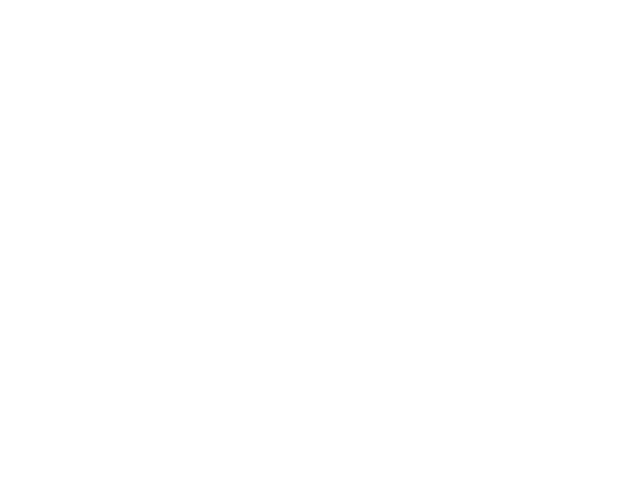

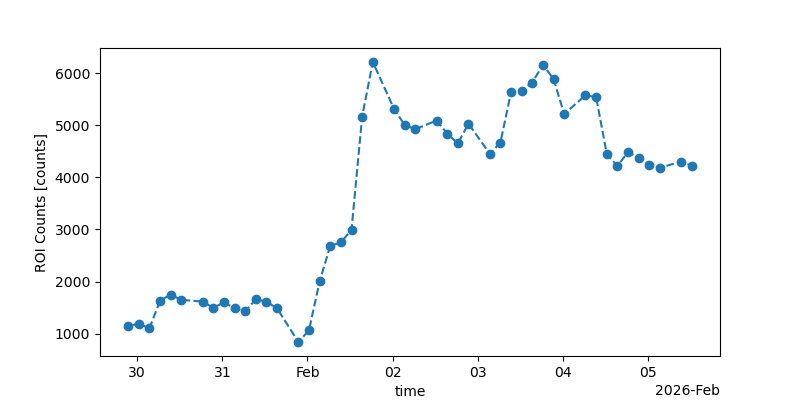

In [12]:
# Plot ROI counts per sample
plt.figure()
data_hdrsci.roi_count.plot(ls="--", x="time", marker="o", figsize=(8,4))

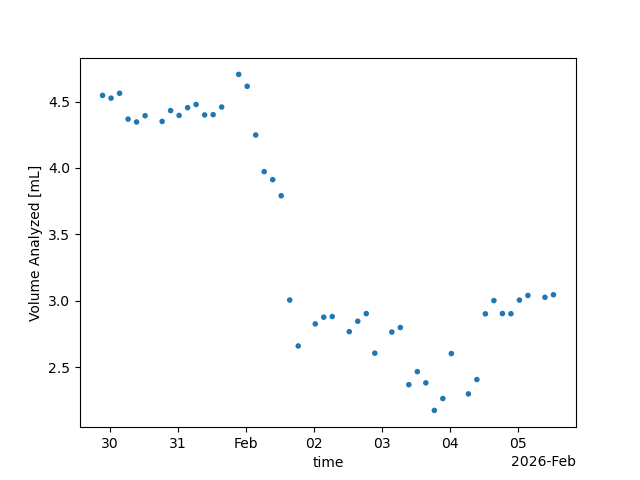

In [13]:
plt.figure()
data_hdrsci.volume_analyzed.plot.scatter(x="time", edgecolors="none", s=16)

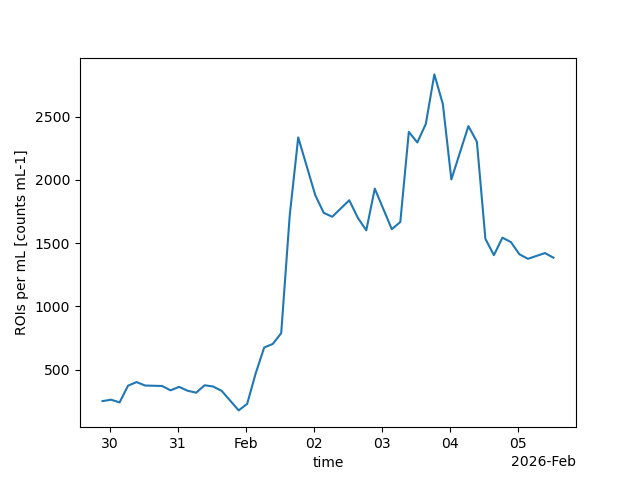

In [14]:
plt.figure()
data_hdrsci.rois_per_ml.plot(x="time")

#### Telemetered ADC science data stream

In [15]:
# Setup parameters needed to request data
refdes = datastreams.refdes[3]
method = datastreams.method[3]
stream = datastreams.stream[3]

In [16]:
# Import vocabulary
site, node, sensor = refdes.split('-', 2)
# vocab = get_vocabulary(site, node, sensor)

In [17]:
# Use the gold copy THREDDs datasets
thredds_url = M2M.get_thredds_url(refdes, method, stream, beginDT=start, endDT=end)

# Get the THREDDs catalog
thredds_catalog = M2M.get_thredds_catalog(thredds_url)
thredds_catalog = [x for x in thredds_catalog if "blank" not in x]

# Clean the THREDDs catalog
sensor_files, ancillary_files = M2M.clean_catalog(thredds_catalog, stream)

# Generate the urls to access and load the data
sensor_files = [re.sub("catalog.html\?dataset=", M2M.URLS["dodsC"], file) for file in sensor_files]

Waiting for request to process
Waiting for request to process
Waiting for request to process
Waiting for request to process
Waiting for request to process
Waiting for request to process


In [18]:
# Load the data
with ProgressBar():
    data_adcsci = xr.open_mfdataset(sensor_files, parallel=True)

[########################################] | 100% Completed | 2.05 ss


In [19]:
# Check dataset content
data_adcsci

<xarray.Dataset> Size: 63MB
Dimensions:                     (obs: 216323)
Coordinates:
  * obs                         (obs) int32 865kB 0 1 2 ... 216320 216321 216322
    time                        (obs) datetime64[ns] 2MB dask.array<chunksize=(216323,), meta=np.ndarray>
Data variables: (12/26)
    driver_timestamp            (obs) datetime64[ns] 2MB dask.array<chunksize=(216323,), meta=np.ndarray>
    id                          (obs) |S64 14MB dask.array<chunksize=(216323,), meta=np.ndarray>
    inhibit_time_tr             (obs) float32 865kB dask.array<chunksize=(216323,), meta=np.ndarray>
    peak_b                      (obs) float32 865kB dask.array<chunksize=(216323,), meta=np.ndarray>
    peak_a                      (obs) float32 865kB dask.array<chunksize=(216323,), meta=np.ndarray>
    grab_time_start             (obs) float32 865kB dask.array<chunksize=(216323,), meta=np.ndarray>
    ...                          ...
    run_time_tr                 (obs) float32 865kB dask.array<chunksize=(216323,), meta=np.ndarray>
    roi_height                  (obs) float64 2MB dask.array<chunksize=(216323,), meta=np.ndarray>
    port_timestamp              (obs) datetime64[ns] 2MB dask.array<chunksize=(216323,), meta=np.ndarray>
    deployment                  (obs) int32 865kB dask.array<chunksize=(216323,), meta=np.ndarray>
    preferred_timestamp         (obs) object 2MB dask.array<chunksize=(216323,), meta=np.ndarray>
    sample_filename             (obs) object 2MB dask.array<chunksize=(216323,), meta=np.ndarray>
Attributes: (12/73)
    node:                               RID27
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  telemetered
    stream:                             plims_a_adc_instrument
    ...                                 ...
    geospatial_vertical_positive:       down
    lat:                                35.950317
    lon:                                -75.11953
    DODS.strlen:                        24
    DODS.dimName:                       string24
    DODS_EXTRA.Unlimited_Dimension:     obs

In [20]:
# Check time values for triggers compared to sample time
print(data_adcsci.sample_timestamp[0].values) # Sample start time
print(data_adcsci.grab_time_start[0].values) # Time elapsed in seconds since the sample start time
print(data_adcsci.time[0].values) # Time of the first trigger of the sample

2026-01-29T18:25:45.000000000
661.66034
2026-01-29T18:36:46.660319744


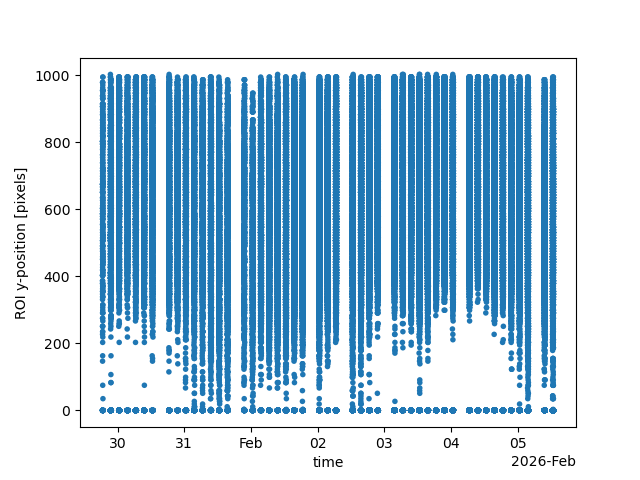

In [22]:
plt.figure()
data_adcsci.roi_y.plot.scatter(x="time", edgecolors="none", s=16)

## Compare ROI count and average ROI size

Text(0.5, 1.0, 'ROI sizes from 2026-01-29 to 2026-02-05')

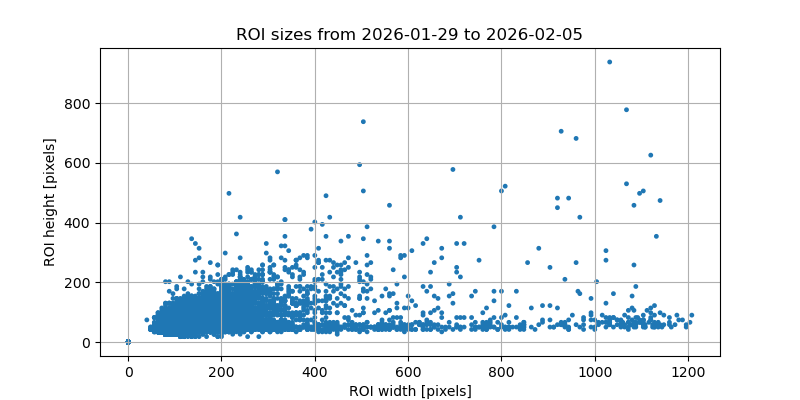

In [23]:
# Plot ROI width v. ROI height
plt.figure(figsize=(8,4))
plt.scatter(data_adcsci["roi_width"], data_adcsci["roi_height"], edgecolors="none", s=12)
plt.grid()
plt.ylabel("ROI height [pixels]")
plt.xlabel("ROI width [pixels]")
plt.title(f"ROI sizes from {np.datetime_as_string(data_adcsci.time[0].values, unit='D')} \
to {np.datetime_as_string(data_adcsci.time[-1].values, unit='D')}")

Text(0, 0.5, 'ROI size [pixels]')

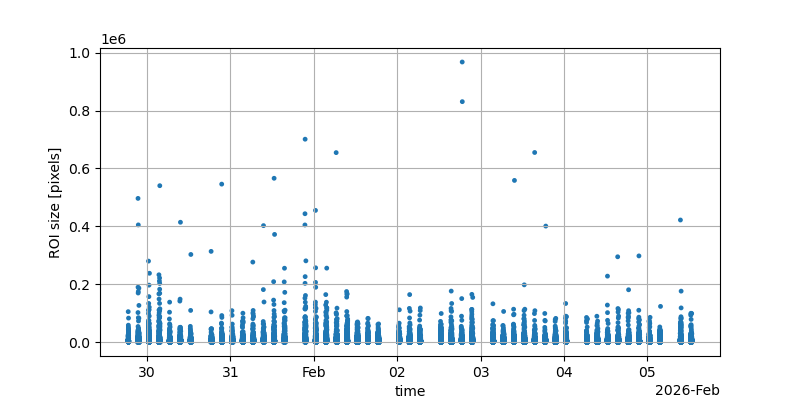

In [24]:
# plot ROI size in pixels over time
roi_size = data_adcsci["roi_width"] * data_adcsci["roi_height"]
# roi_size

plt.figure(figsize=(8,4))
roi_size.plot.scatter(edgecolors="none", s=12, x="time")
plt.grid()
plt.ylabel("ROI size [pixels]")

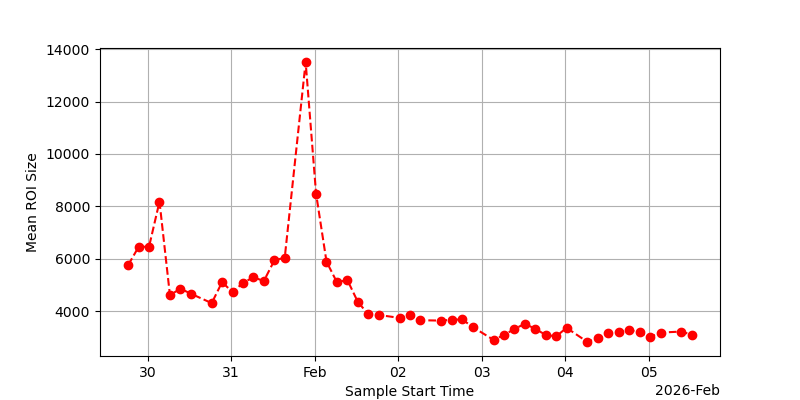

In [25]:
# Sort data by sample and compute mean ROI size
mean_roi_size = xr.DataArray(
    roi_size.groupby(data_adcsci["sample_timestamp"]).mean(),
    name="Mean ROI Size"
)
# mean_roi_size

# plot mean ROI size
plt.figure(figsize=(8,4))
mean_roi_size.plot(c="r", ls="--", marker="o", x="sample_timestamp")
plt.grid()
# plt.ylabel("ROI size [pixels]")

Text(0, 0.5, 'ROI size [pixels]')

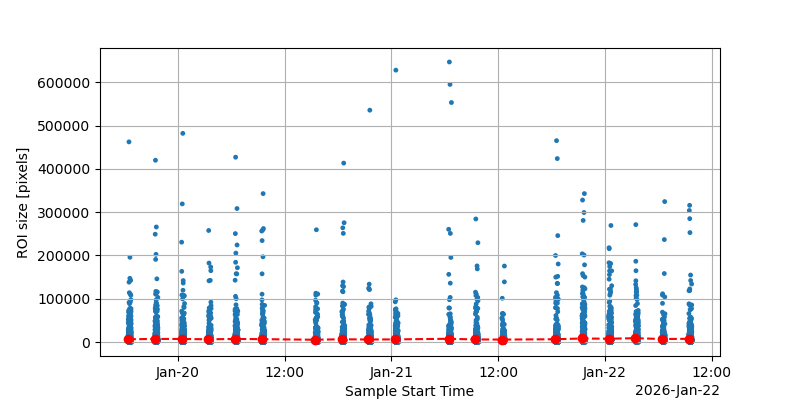

In [25]:
# Plot ROI size and mean ROI size on the same axes
plt.figure(figsize=(8,4))
roi_size.plot.scatter(edgecolors="none", s=12, x="time")
mean_roi_size.plot(c="r", ls="--", marker="o", x="sample_timestamp")
plt.grid()
plt.ylabel("ROI size [pixels]")

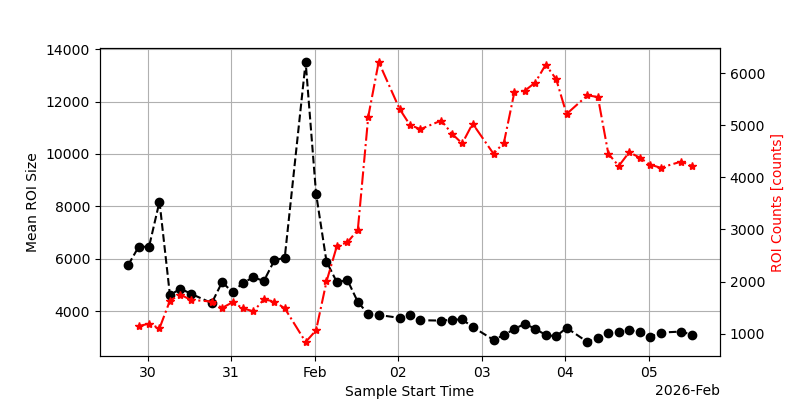

In [26]:
# plot ROI count and mean ROI size on twin axes
plt.figure(figsize=(8,4))
mean_roi_size.plot(marker="o", ls="--", c="k", x="sample_timestamp")
plt.grid()
ax2 = plt.twinx()
data_hdrsci["roi_count"].plot(marker="*", c="r", ls="-.", x="time")
ax2.axes.yaxis.label.set_color("r")